In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
def quadratic(x, a, b, c):
    return a*x**2 + b*x + c

def linear(x, a, b):
    return a*x +b

def calculate_ridberg_ind(n, array):
    return pow( (array[n-3] * (1/2**2 - 1/n**2) ) , -1)

def calculate_ridberg_error(l, lerr, m):
    c = pow((1/2**2 - 1/m**2), -1)
    return c*lerr/l**2

def error(x, a, b, c, aerr, berr, cerr, xerr=1):
    dfda = x**2
    dfdb = x
    dfdc = 1
    dfdx = 2*a*x + b
    
    result = np.sqrt( (dfda * aerr)**2 + (dfdb * berr)**2 + (dfdc * cerr)**2 + (dfdx * xerr)**2 )
    return result

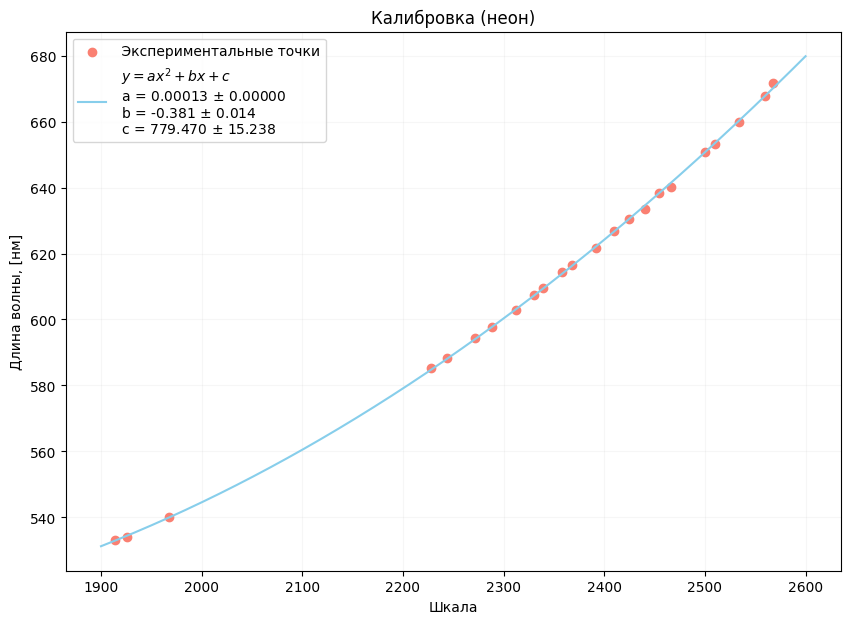

In [3]:
nums = np.arange(3, 26)[::-1]
array = np.array([1914, 1926, 1968, 2228,
                  2244, 2272, 2288, 2312,
                  2330, 2339, 2358, 2368,
                  2392, 2410, 2425, 2440,
                  2454, 2466, 2500, 2510, 
                  2534, 2560, 2568])
wl = np.array([6717, 6678,6599, 6533, 
               6507, 6402, 6383, 6334, 
               6305, 6267, 6217, 6164,
               6143, 6096, 6074, 6030,
               5976, 5945, 5882, 5852,
               5401, 5341, 5331])
wl = wl/10
wl = wl[::-1]

popt, pcov = curve_fit(quadratic, array, wl)
a_neon, b_neon, c_neon = popt
a_neon_err, b_neon_err, c_neon_err = np.sqrt(np.diag(pcov))
name_neon = f' $y = ax^2 + bx + c$\n a = {a_neon:.5f} $\pm$ {a_neon_err:.5f}\n b = {b_neon:.3f} $\pm$ {b_neon_err:.3f}\n c = {c_neon:.3f} $\pm$ {c_neon_err:.3f}'

plt.figure(figsize=(10, 7))
plt.scatter(array, wl, c='salmon', label=' Экспериментальные точки')
plt.plot(np.linspace(1900, 2600, 1000), quadratic(np.linspace(1900, 2600, 1000), *popt), c='skyblue', label=name_neon)
plt.xlabel('Шкала')
plt.ylabel('Длина волны, [нм]')
plt.title('Калибровка (неон)')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

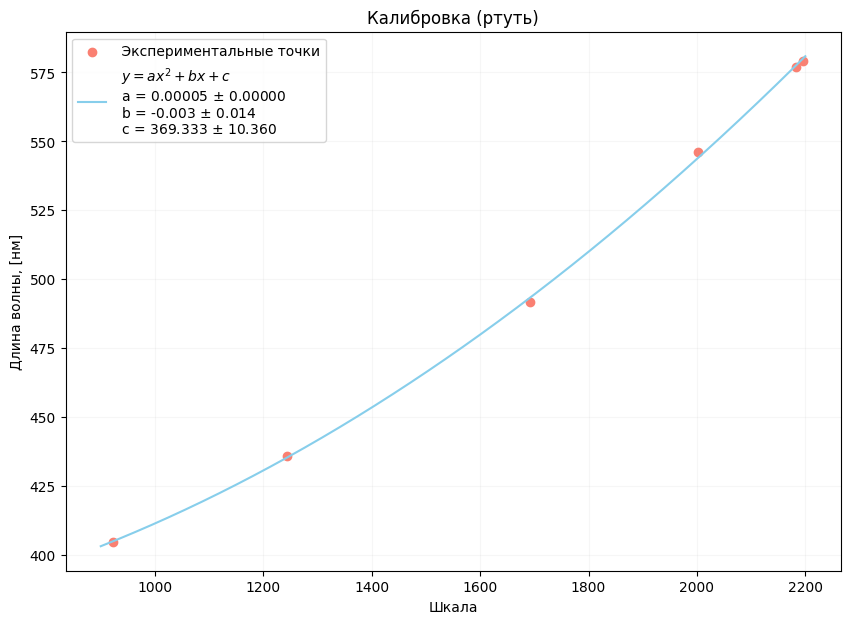

In [5]:
array = np.array([2195, 2182, 2002, 1692, 1244, 922])
nums = np.arange(1, 7)
wl = np.array([579.1, 577, 546.1, 491.6, 435.8, 404.7])

popt, pcov = curve_fit(quadratic, array, wl)
a_hg, b_hg, c_hg = popt
a_hg_err, b_hg_err, c_hg_err = np.sqrt(np.diag(pcov))
name_hg = f' $y = ax^2 + bx + c$\n a = {a_hg:.5f} $\pm$ {a_hg_err:.5f}\n b = {b_hg:.3f} $\pm$ {b_hg_err:.3f}\n c = {c_hg:.3f} $\pm$ {c_hg_err:.3f}'


plt.figure(figsize=(10, 7))
plt.scatter(array, wl, c='salmon', label=' Экспериментальные точки')
plt.plot(np.linspace(900, 2200, 1000), quadratic(np.linspace(900, 2200, 1000), *popt), c='skyblue', label=name_hg)
plt.xlabel('Шкала')
plt.ylabel('Длина волны, [нм]')
plt.title('Калибровка (ртуть)')
plt.grid(alpha=0.1)
plt.legend()
plt.show()

In [7]:
hydrogen = np.array([2523, 1526, 870, 472])
h_nums = np.array([1, 2, 3, 4])
iodine = np.array([2364, 2265, 1832]) # Первая, шестая и последняя перед непрерывным спектром

In [11]:
hydrogen_wl_series = quadratic(hydrogen, a_hg, b_hg, c_hg)
hydrogen_error = error(hydrogen_wl_series, a=a_hg, b=b_hg, c=c_hg, aerr=a_hg_err, berr=b_hg_err, cerr=c_hg_err)


hydrogen_df = pd.DataFrame({'Balmer series, [nm]': np.array([656.28, 486.13, 434.05, 410.17]),
                           'Calculated wavelength, [nm]': hydrogen_wl_series,
                           'Error, [nm]': hydrogen_error})
hydrogen_df

,"Balmer series, [nm]","Calculated wavelength, [nm]","Error, [nm]"
0,656.28,648.624455,13.945296
1,486.13,469.619831,12.334766
2,434.05,400.760446,11.822802
3,410.17,377.908229,11.667635


In [22]:
error(hydrogen_wl_series, a=a_hg, b=b_hg, c=c_hg, aerr=a_hg_err, berr=b_hg_err, cerr=c_hg_err)

array([101.04321602,  88.72411224,  85.38572004,  84.68615802])

===== ПОСТОЯННАЯ РИДБЕРГА =====
13338726 ± 585170


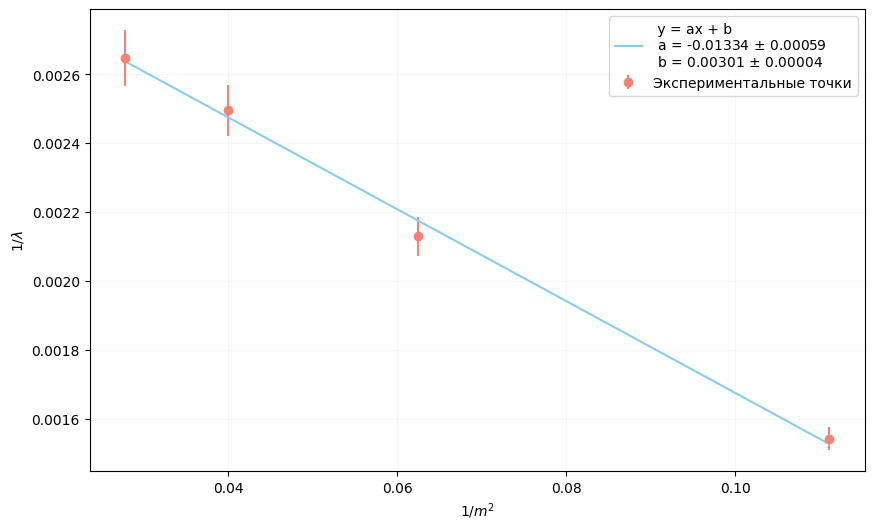

In [86]:
popt, pcov = curve_fit(linear, 1/(h_nums+2)**2, 1/hydrogen_wl_series)
a_rid, b_rid = popt
a_rid_err, b_rid_err = np.sqrt(np.diag(pcov))
print('===== ПОСТОЯННАЯ РИДБЕРГА =====')
print(f'{-round(a_rid * pow(10, 9))} ± {round(a_rid_err * pow(10, 9))}')
name_ridberg = f' y = ax + b\n a = {a_rid:.5f} $\pm$ {a_rid_err:.5f}\n b = {b_rid:.5f} $\pm$ {b_rid_err:.5f}'

plt.figure(figsize=(10, 6))
plt.errorbar(1/(h_nums+2)**2, 1/hydrogen_wl_series, yerr=hydrogen_error/hydrogen_wl_series**2, fmt='o', c='salmon', label='Экспериментальные точки')
plt.plot(1/(h_nums+2)**2, linear(1/(h_nums+2)**2, *popt), c='skyblue', label=name_ridberg)
plt.xlabel('$1/m^2$')
plt.ylabel('$1/\\lambda$')
plt.legend()
plt.grid(alpha=0.1)
plt.show()

In [82]:
ridberg_table = {'Табличное': [10973731],
                 'Из графика': [f'{-round(a_rid * pow(10, 9))} ± {round(a_rid_err * pow(10, 9))}']}
for i, val in enumerate(pow(10, 9) * calculate_ridberg_ind(np.arange(3, 7), hydrogen_wl_series)):
    ridberg_table[f'{i+1}-я линия'] = [f'{round(val)} ± {round(pow(10, 9) * calculate_ridberg_error(hydrogen_wl_series[i], hydrogen_error[0], i+3))}']
pd.DataFrame(ridberg_table).T

,0
Табличное,10973731
Из графика,13338726 ± 585170
1-я линия,11100414 ± 238657
2-я линия,11356704 ± 337236
3-я линия,11882173 ± 413465
4-я линия,11907653 ± 439408


In [13]:
iod_wl = quadratic(iodine, a_hg, b_hg, c_hg)
iod_wl_error = error(iod_wl, a=a_hg, b=b_hg, c=c_hg, aerr=a_hg_err, berr=b_hg_err, cerr=c_hg_err)
iod_freq = 3 * pow(10, 17)/iod_wl
iod_freq_error = 3 * pow(10, 17) * iod_wl_error/iod_wl**2

iod_df = pd.DataFrame({'Number': np.array([1, 6, 'last']),
                       'Calculated wavelength, [nm]': iod_wl,
                       'WL Error, [nm]': iod_wl_error,
                       'Freq, [THz]': pow(10, -12) * iod_freq,
                       'Freq Error, [THz]': pow(10, -12) * iod_freq_error})
iod_df

,Number,"Calculated wavelength, [nm]","WL Error, [nm]","Freq, [THz]","Freq Error, [THz]"
0,1,614.065899,13.605550,488.546914,10.824489
1,6,593.700628,13.411479,505.305176,11.414658
2,last,515.020734,12.706802,582.500820,14.371699


In [104]:
h = 4.1 * pow(10, -15) # in eV
hv2 = (iod_freq[1] - iod_freq[0]) * (h/5)
hv2_error = (np.sqrt(iod_freq_error[0]**2 + iod_freq_error[1]**2)) * (h/5)
print('Колебательный квант возб. (hν2):', hv2, '±', hv2_error)

Колебательный квант возб. (hν2): 0.013741774324859702 ± 0.0128994102489767


In [106]:
E = h * iod_freq[0] - hv2/2 + 1.5*0.027
E_error = np.sqrt( (h*iod_freq_error[0])**2 + (hv2_error/2)**2 )
print('Энергия эл. перехода (T_e):', E, '±', E_error)

Энергия эл. перехода (T_e): 2.036671461118231 ± 0.04484661760708767


In [109]:
D1 = h * iod_freq[-1] - 0.94
D1_error = h * iod_freq_error[-1]
print('Энергия диссоциации осн. (D1):', D1, '±', D1_error)

Энергия диссоциации осн. (D1): 1.4482533633004295 ± 0.05892396408995413


In [110]:
D2 = h * iod_freq[-1] - E
D2_error = np.sqrt( (h * iod_freq_error[-1])**2 + (E_error)**2 )
print('Энергия диссоциации возб. (D2):', D2, '±', D2_error)

Энергия диссоциации возб. (D2): 0.35158190218219865 ± 0.07404898820963424
